In [1]:
import os
from pathlib import Path

import japanize_matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from google.cloud import bigquery

load_dotenv()

PROJECT_ID = os.environ["GOOGLE_CLOUD_PROJECT"]
LOCATION = os.environ["BIGQUERY_LOCATION"]

client = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT
  fiscal_year,
  industry_name,
  capital_size_name,
  net_sales_million_yen,
  ordinary_income_margin_pct,
  net_assets_ratio_pct,
  personnel_cost_ratio_pct,
  real_investment_ratio_pct
FROM
  `{PROJECT_ID}.corporate_finance_mart.financial_kpis`
ORDER BY
  fiscal_year,
  industry_name,
  capital_size_name
"""

rows = [dict(row.items()) for row in client.query(query, location=LOCATION).result()]
df = pd.DataFrame(rows)

print(df.shape)
df.head()

(90, 8)


,fiscal_year,industry_name,capital_size_name,net_sales_million_yen,ordinary_income_margin_pct,net_assets_ratio_pct,personnel_cost_ratio_pct,real_investment_ratio_pct
0,2016,卸売業・小売業(集約),10億円以上,148769488,2.7828751,37.113734,3.3119963,1.0962463
1,2016,卸売業・小売業(集約),1億円以上 - 10億円未満,115527934,2.0299991,32.8034962,4.1846624,0.867752
2,2016,卸売業・小売業(集約),1千万円未満,42629192,1.1458627,29.7318702,6.4151861,1.0973537
3,2016,情報通信業,10億円以上,34259944,14.5075981,60.5218192,6.7968383,7.5925868
4,2016,情報通信業,1億円以上 - 10億円未満,17231431,6.2956698,55.7518418,15.6831142,2.9137162


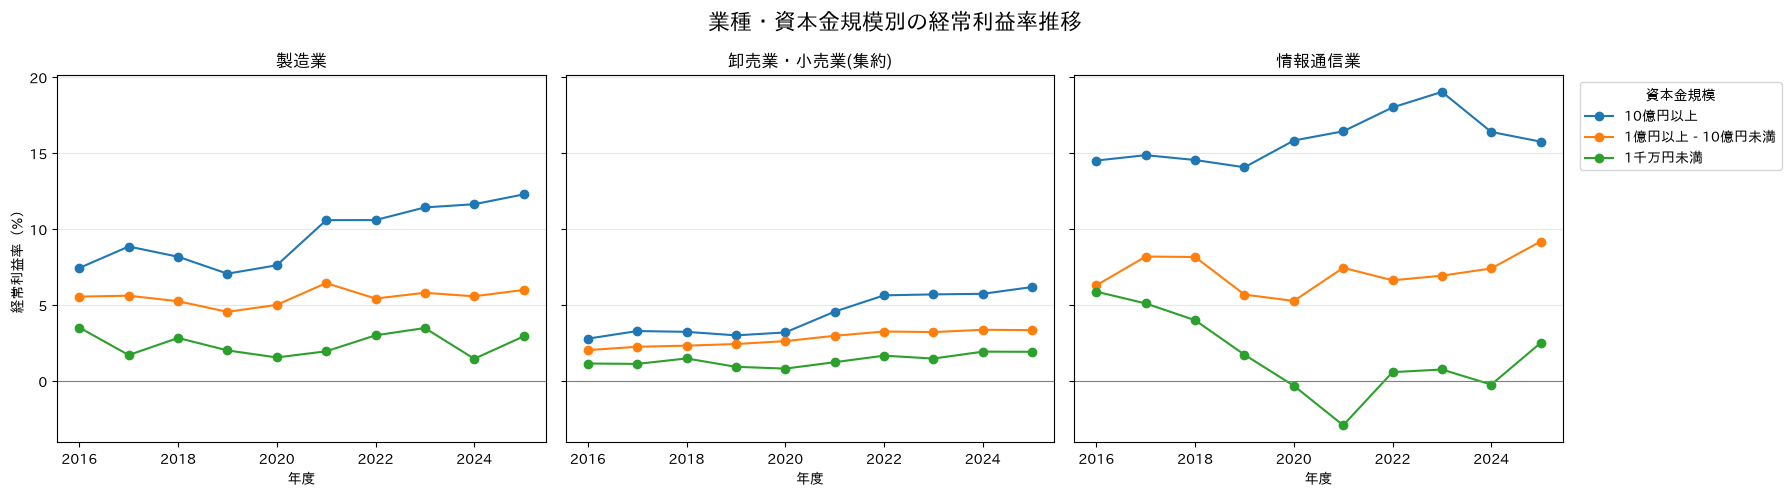

In [2]:
industries = ["製造業", "卸売業・小売業(集約)", "情報通信業"]

fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 5),
    sharey=True,
)

for ax, industry in zip(axes, industries):
    subset = df[df["industry_name"] == industry]

    for capital_size, group in subset.groupby("capital_size_name"):
        group = group.sort_values("fiscal_year")

        ax.plot(
            group["fiscal_year"],
            group["ordinary_income_margin_pct"],
            marker="o",
            label=capital_size,
        )

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.set_title(industry)
    ax.set_xlabel("年度")
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("経常利益率（%）")
axes[-1].legend(title="資本金規模", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.suptitle("業種・資本金規模別の経常利益率推移", fontsize=16)
fig.tight_layout()

output_path = Path("../docs/images/ordinary_income_margin_trends.png")
output_path.parent.mkdir(parents=True, exist_ok=True)

fig.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

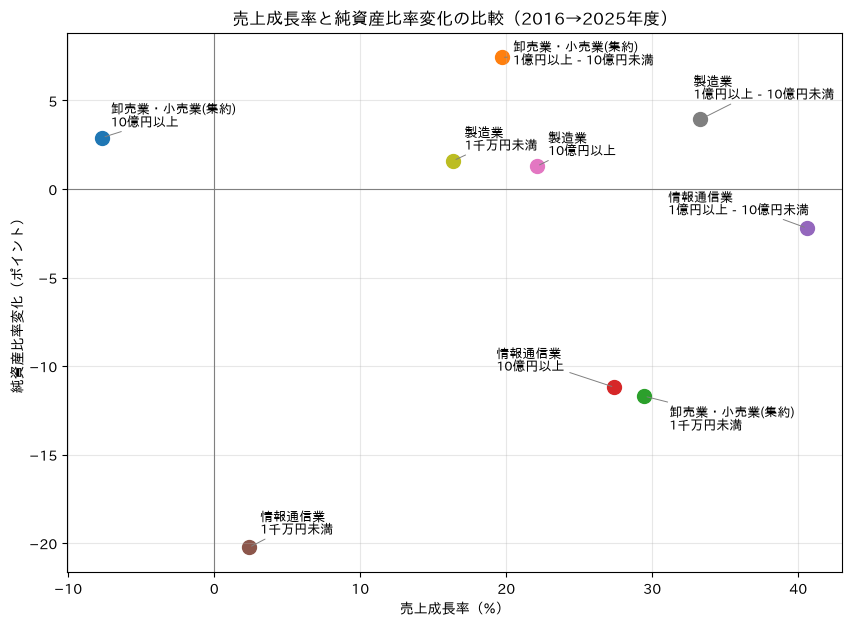

In [20]:
comparison = (
    df[df["fiscal_year"].isin([2016, 2025])]
    .pivot(
        index=["industry_name", "capital_size_name"],
        columns="fiscal_year",
        values=["net_sales_million_yen", "net_assets_ratio_pct"],
    )
    .reset_index()
)

comparison.columns = [
    "_".join(map(str, column)).strip("_")
    for column in comparison.columns
]

comparison["net_sales_growth_pct"] = (
    (
        comparison["net_sales_million_yen_2025"]
        - comparison["net_sales_million_yen_2016"]
    )
    / comparison["net_sales_million_yen_2016"]
    * 100
)

comparison["net_assets_ratio_change_pp"] = (
    comparison["net_assets_ratio_pct_2025"]
    - comparison["net_assets_ratio_pct_2016"]
)

fig, ax = plt.subplots(figsize=(10, 7))

offsets = {
    ("卸売業・小売業(集約)", "10億円以上"): (6, 8),
    ("卸売業・小売業(集約)", "1億円以上 - 10億円未満"): (8, -5),
    ("卸売業・小売業(集約)", "1千万円未満"): (18, -24),

    # 下部で重なりやすい3点を意図的に分離
    ("情報通信業", "10億円以上"): (-85, 12),
    ("情報通信業", "1億円以上 - 10億円未満"): (-100, 10),
    ("情報通信業", "1千万円未満"): (8, 10),

    ("製造業", "10億円以上"): (8, 8),
    ("製造業", "1億円以上 - 10億円未満"): (-5, 15),
    ("製造業", "1千万円未満"): (8, 8),
}

for _, row in comparison.iterrows():
    ax.scatter(
        row["net_sales_growth_pct"],
        row["net_assets_ratio_change_pp"],
        s=100,
    )

    label = f"{row['industry_name']}\n{row['capital_size_name']}"
    offset = offsets[(row["industry_name"], row["capital_size_name"])]

    ax.annotate(
    label,
    (
        row["net_sales_growth_pct"],
        row["net_assets_ratio_change_pp"],
    ),
    xytext=offset,
    textcoords="offset points",
    fontsize=9,
    arrowprops={"arrowstyle": "-", "color": "gray", "lw": 0.7},
    )

ax.axhline(0, color="gray", linewidth=0.8)
ax.axvline(0, color="gray", linewidth=0.8)

ax.set_title("売上成長率と純資産比率変化の比較（2016→2025年度）")
ax.set_xlabel("売上成長率（%）")
ax.set_ylabel("純資産比率変化（ポイント）")
ax.grid(alpha=0.3)

output_path = Path("../docs/images/sales_growth_vs_net_assets_change.png")
fig.savefig(output_path, dpi=200, bbox_inches="tight")

plt.show()